## Part 2 — Adam-Family Optimizer

## Purpose and hypotheses

**H2-OPT.** Adam-family methods should cross a validation-loss threshold in fewer gradient evaluations and less wall time than plain SGD. Momentum and Nesterov should reduce SGD trajectory variance. Removing Adam bias correction should be most harmful early in training, while `beta1=0` should produce noisier trajectories. AdamW may improve validation behavior only if its decoupled weight decay is useful at the fixed budget.

All tuning uses the training and validation splits only. The main seven-condition comparison uses identical optimizer-update budgets and at least three seeds in full mode. The test set is evaluated only after learning rates, Adam hyperparameters, the threshold, and the ranking rule are locked.

In [1]:
from pathlib import Path
from copy import deepcopy
import os, math, platform, random, time, json, warnings
from dataclasses import dataclass, asdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from IPython.display import display
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, f1_score, precision_recall_fscore_support,
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

# reproducibility and run modes
BASE_SEED = 42
FULL_SEEDS = [42, 202, 7641]
SMOKE_TEST = os.getenv("OL_SMOKE_TEST", "0") == "1"
QUICK_MODE = os.getenv("OL_QUICK_MODE", "0") == "1" or SMOKE_TEST
SEEDS = [42] if QUICK_MODE else FULL_SEEDS
DEVICE = torch.device(os.getenv("OL_DEVICE", "cpu"))
TORCH_THREADS = max(1, min(4, os.cpu_count() or 1))
torch.set_num_threads(TORCH_THREADS)

def set_all_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True, warn_only=True)

set_all_seeds(BASE_SEED)

# input directories
DATA_PATH = Path("output_data/eda_dataset_original/dataset_stratified.csv")
DATA_PATH_TEST = Path("output_data/eda_dataset_original/dataset_remainder.csv")
RAW_DATA_PATH = Path("dataset_covertype/covtype.data")
TARGET_COL = "Cover_Type"

# Values are fixed by the SL Report notebook.
SL_ARCHITECTURE = (64, 64)
SL_LEARNING_RATE = 0.10
SL_BATCH_SIZE = 512
SL_WEIGHT_DECAY = 1e-4
SL_MAX_EPOCHS = 70
SL_PATIENCE = 10

# Exact SL-notebook reference result from the output.
SL_REFERENCE = {
    "method": "SL PyTorch SGD-only reference",
    "architecture": str(SL_ARCHITECTURE),
    "parameter_count": 8135,
    "learning_rate": 0.10,
    "batch_size": 512,
    "weight_decay": 1e-4,
    "best_epoch": 26,
    "epochs_run": 36,
    "test_accuracy": 0.6400986075,
    "test_macro_f1": 0.5526402660,
    "test_balanced_accuracy": 0.7019769460,
    "fit_time_sec_on_original_hardware": 2.675669709,
}

### 1. Data loading: Exact SL report split and processing

In [2]:
df_source = pd.read_csv(DATA_PATH)
df_test_external = pd.read_csv(DATA_PATH_TEST)

assert TARGET_COL in df_source.columns and TARGET_COL in df_test_external.columns
feature_cols = [c for c in df_source.columns if c != TARGET_COL]
assert len(feature_cols) == 54, f"Expected 54 features, found {len(feature_cols)}"
assert list(df_test_external.columns) == list(df_source.columns), "Development/test columns differ."
assert len(df_source) == 20_000, f"Expected 20,000 sampled rows, found {len(df_source)}"
assert len(df_test_external) == 561_012, f"Expected 561,012 remainder rows, found {len(df_test_external)}"
assert df_source.isna().sum().sum() == 0 and df_test_external.isna().sum().sum() == 0

X_source_df = df_source[feature_cols].copy()
y_source_raw = df_source[TARGET_COL].copy()
X_test_df = df_test_external[feature_cols].copy()
y_test_raw = df_test_external[TARGET_COL].copy()

### 2. Reproducing the SL-report notebook stable class mapping

In [3]:
label_encoder = LabelEncoder()
label_encoder.fit(pd.concat([y_source_raw, y_test_raw], ignore_index=True))
class_labels = label_encoder.classes_
classes = np.arange(len(class_labels))
class_names = [f"Cover_Type_{c}" for c in class_labels]

X_train_df, X_val_df, y_train_raw, y_val_raw = train_test_split(
    X_source_df,
    y_source_raw,
    test_size=0.20,
    stratify=y_source_raw,
    random_state=BASE_SEED,
)

y_train = label_encoder.transform(y_train_raw).astype(np.int64)
y_val = label_encoder.transform(y_val_raw).astype(np.int64)
y_test = label_encoder.transform(y_test_raw).astype(np.int64)

### 3. Leakage safety: fittin learned scalling only on 16K rows training split

In [4]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df).astype(np.float32)
X_val = scaler.transform(X_val_df).astype(np.float32)
X_test = scaler.transform(X_test_df).astype(np.float32)

class_weights_np = compute_class_weight(
    class_weight="balanced", classes=classes, y=y_train
).astype(np.float32)
class_weights_t = torch.tensor(class_weights_np, dtype=torch.float32, device=DEVICE)

X_train_t = torch.tensor(X_train, dtype=torch.float32, device=DEVICE)
y_train_t = torch.tensor(y_train, dtype=torch.long, device=DEVICE)
X_val_t = torch.tensor(X_val, dtype=torch.float32, device=DEVICE)
y_val_t = torch.tensor(y_val, dtype=torch.long, device=DEVICE)
X_test_t = torch.tensor(X_test, dtype=torch.float32, device=DEVICE)
y_test_t = torch.tensor(y_test, dtype=torch.long, device=DEVICE)

steps_per_epoch = math.ceil(len(y_train) / SL_BATCH_SIZE)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "source": [DATA_PATH.name, DATA_PATH.name, DATA_PATH_TEST.name],
    "rows": [len(y_train), len(y_val), len(y_test)],
    "purpose": ["fit", "selection only", "final locked evaluation only"],
})
display(split_summary)

print({
    "device": str(DEVICE),
    "torch": torch.__version__,
    "python": platform.python_version(),
    "cpu": platform.processor() or platform.machine(),
    "torch_threads": TORCH_THREADS,
    "quick_mode": QUICK_MODE,
    "seeds": SEEDS,
    "steps_per_epoch": steps_per_epoch,
})


,split,source,rows,purpose
0,train,dataset_stratified.csv,16000,fit
1,validation,dataset_stratified.csv,4000,selection only
2,test,dataset_remainder.csv,561012,final locked evaluation only


{'device': 'cpu', 'torch': '2.5.1', 'python': '3.11.15', 'cpu': 'x86_64', 'torch_threads': 4, 'quick_mode': False, 'seeds': [42, 202, 7641], 'steps_per_epoch': 32}


### 4. Fixing PyTorch backbone with permitted dropout regularizaiton

In [5]:
class CompactMLP(nn.Module):
    """The exact 54 -> 64 -> 64 -> 7 SL backbone.

    Dropout modules are inserted only when Part 3/4 explicitly studies regularization;
    all Linear layer dimensions and ReLU placements remain unchanged.
    """
    def __init__(self, input_dim=54, hidden_layers=SL_ARCHITECTURE, output_dim=7, dropout=0.0):
        super().__init__()
        layers = []
        prev = input_dim
        for width in hidden_layers:
            layers.extend([nn.Linear(prev, width), nn.ReLU()])
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = width
        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)
        self.dropout = float(dropout)

    def forward(self, x):
        return self.net(x)


def count_parameters(model, trainable_only=True):
    params = (p for p in model.parameters() if (p.requires_grad or not trainable_only))
    return sum(p.numel() for p in params)


_base_model_check = CompactMLP().to(DEVICE)
assert count_parameters(_base_model_check) == 8135
print(f"Backbone parameter count confirmed: {count_parameters(_base_model_check):,}")
del _base_model_check

Backbone parameter count confirmed: 8,135


### 5. Metrics and Evaluation

In [6]:
def metric_dict(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
    }


def make_criterion(label_smoothing=0.0):
    return nn.CrossEntropyLoss(weight=class_weights_t, label_smoothing=float(label_smoothing))


def evaluate_tensor(model, X_t, y_t, criterion):
    model.eval()
    with torch.inference_mode():
        logits = model(X_t)
        loss = float(criterion(logits, y_t).item())
        pred = logits.argmax(dim=1).cpu().numpy()
    out = metric_dict(y_t.cpu().numpy(), pred)
    out["loss"] = loss
    return out, pred


def full_report(y_true, y_pred):
    report = pd.DataFrame(classification_report(
        y_true, y_pred, labels=classes, target_names=class_names,
        output_dict=True, zero_division=0,
    )).T
    cm = pd.DataFrame(
        confusion_matrix(y_true, y_pred, labels=classes),
        index=class_names, columns=class_names,
    )
    return report, cm


def clone_state(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


def load_state(model, state):
    model.load_state_dict({k: v.to(DEVICE) for k, v in state.items()})

### 6. Adam without bias correction

In [7]:
class AdamNoBiasCorrection(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
        if lr <= 0:
            raise ValueError("lr must be positive")
        defaults = dict(lr=lr, betas=betas, eps=eps)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None if closure is None else closure()
        for group in self.param_groups:
            beta1, beta2 = group["betas"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                g = p.grad
                if g.is_sparse:
                    raise RuntimeError("Sparse gradients are not supported.")
                state = self.state[p]
                if not state:
                    state["step"] = 0
                    state["exp_avg"] = torch.zeros_like(p)
                    state["exp_avg_sq"] = torch.zeros_like(p)
                state["step"] += 1
                m, v = state["exp_avg"], state["exp_avg_sq"]
                m.mul_(beta1).add_(g, alpha=1 - beta1)
                v.mul_(beta2).addcmul_(g, g, value=1 - beta2)
                p.addcdiv_(m, v.sqrt().add_(group["eps"]), value=-group["lr"])
        return loss


def build_optimizer(name, model, lr, beta1=0.9, beta2=0.999, weight_decay=0.0):
    params = [p for p in model.parameters() if p.requires_grad]
    if name == "sgd":
        return torch.optim.SGD(params, lr=lr, momentum=0.0, weight_decay=weight_decay)
    if name == "sgd_momentum":
        return torch.optim.SGD(params, lr=lr, momentum=0.9, nesterov=False, weight_decay=weight_decay)
    if name == "sgd_nesterov":
        return torch.optim.SGD(params, lr=lr, momentum=0.9, nesterov=True, weight_decay=weight_decay)
    if name == "adam":
        return torch.optim.Adam(params, lr=lr, betas=(beta1, beta2), weight_decay=weight_decay)
    if name == "adam_no_bias_correction":
        return AdamNoBiasCorrection(params, lr=lr, betas=(beta1, beta2))
    if name == "adam_beta1_zero":
        return torch.optim.Adam(params, lr=lr, betas=(0.0, beta2), weight_decay=weight_decay)
    if name == "adamw":
        return torch.optim.AdamW(params, lr=lr, betas=(beta1, beta2), weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer: {name}")

### 7. Controlled-budget trainer

In [8]:
@dataclass
class TrainConfig:
    optimizer_name: str
    lr: float
    max_updates: int
    batch_size: int = SL_BATCH_SIZE
    beta1: float = 0.9
    beta2: float = 0.999
    weight_decay: float = 0.0
    dropout: float = 0.0
    label_smoothing: float = 0.0
    input_noise_std: float = 0.0
    early_stopping_patience: int | None = None
    selection_metric: str = "val_loss"
    restore_best: bool = True
    eval_every_updates: int = steps_per_epoch


def train_controlled(config: TrainConfig, seed: int, initial_state=None):
    set_all_seeds(seed)
    model = CompactMLP(dropout=config.dropout).to(DEVICE)
    if initial_state is not None:
        load_state(model, initial_state)
    criterion = make_criterion(config.label_smoothing)
    optimizer = build_optimizer(
        config.optimizer_name, model, config.lr, config.beta1, config.beta2, config.weight_decay
    )

    n = len(y_train)
    update = 0
    history = []
    start_time = time.perf_counter()
    best_score = np.inf if config.selection_metric == "val_loss" else -np.inf
    best_state = clone_state(model)
    best_update = 0
    stale_evals = 0
    stopped_early = False
    interval_loss_sum = 0.0
    interval_examples = 0

    while update < config.max_updates:
        model.train()
        permutation = torch.randperm(n, device=DEVICE)
        for batch_start in range(0, n, config.batch_size):
            if update >= config.max_updates:
                break
            idx = permutation[batch_start: batch_start + config.batch_size]
            xb = X_train_t[idx]
            if config.input_noise_std > 0:
                xb = xb + torch.randn_like(xb) * config.input_noise_std
            yb = y_train_t[idx]

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            update += 1
            interval_loss_sum += float(loss.item()) * len(idx)
            interval_examples += len(idx)

            should_eval = (
                update == 1
                or update % config.eval_every_updates == 0
                or update == config.max_updates
            )
            if not should_eval:
                continue

            train_metrics, _ = evaluate_tensor(model, X_train_t, y_train_t, criterion)
            val_metrics, _ = evaluate_tensor(model, X_val_t, y_val_t, criterion)
            elapsed = time.perf_counter() - start_time
            row = {
                "seed": seed,
                "update": update,
                "gradient_evaluations": update,
                "optimizer_updates": update,
                "examples_seen": update * config.batch_size,
                "wall_time_sec": elapsed,
                "interval_train_loss": interval_loss_sum / max(1, interval_examples),
                **{f"train_{k}": v for k, v in train_metrics.items()},
                **{f"val_{k}": v for k, v in val_metrics.items()},
            }
            history.append(row)
            interval_loss_sum = 0.0
            interval_examples = 0

            score = val_metrics[config.selection_metric.replace("val_", "")]
            improved = score < best_score - 1e-6 if config.selection_metric == "val_loss" else score > best_score + 1e-6
            if improved:
                best_score = score
                best_state = clone_state(model)
                best_update = update
                stale_evals = 0
            else:
                stale_evals += 1

            if config.early_stopping_patience is not None and stale_evals >= config.early_stopping_patience:
                stopped_early = True
                break
        if stopped_early:
            break

    total_time = time.perf_counter() - start_time
    final_state = clone_state(model)
    if config.restore_best:
        load_state(model, best_state)
    selected_metrics, selected_pred = evaluate_tensor(model, X_val_t, y_val_t, criterion)

    return {
        "model": model,
        "config": asdict(config),
        "seed": seed,
        "history": pd.DataFrame(history),
        "best_state": best_state,
        "final_state": final_state,
        "best_update": int(best_update),
        "updates_run": int(update),
        "gradient_evaluations": int(update),
        "wall_time_sec": float(total_time),
        "stopped_early": stopped_early,
        "selected_val_metrics": selected_metrics,
        "selected_val_pred": selected_pred,
        "parameter_count": count_parameters(model),
    }


def evaluate_test_locked(run, method_name):
    """Call only after all validation-based choices have been locked."""
    criterion = make_criterion(run["config"].get("label_smoothing", 0.0))
    metrics, pred = evaluate_tensor(run["model"], X_test_t, y_test_t, criterion)
    report, cm = full_report(y_test, pred)
    row = {
        "method": method_name,
        "seed": run["seed"],
        "best_val_loss": run["selected_val_metrics"]["loss"],
        "best_val_macro_f1": run["selected_val_metrics"]["macro_f1"],
        "test_accuracy": metrics["accuracy"],
        "test_macro_f1": metrics["macro_f1"],
        "test_balanced_accuracy": metrics["balanced_accuracy"],
        "wall_time_sec": run["wall_time_sec"],
        "gradient_evaluations": run["gradient_evaluations"],
        "function_evaluations": 0,
        "notes": json.dumps(run["config"], sort_keys=True),
    }
    return row, report, cm, pred


def representative_seed(summary_df, metric="best_val_macro_f1"):
    med = summary_df[metric].median()
    idx = (summary_df[metric] - med).abs().idxmin()
    return int(summary_df.loc[idx, "seed"])


def save_json(path, obj):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, sort_keys=True)


def plot_confusion_matrix(cm_df, title, path):
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm_df.values, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_xticks(range(len(class_labels)), class_labels)
    ax.set_yticks(range(len(class_labels)), class_labels)
    fig.colorbar(im, ax=ax)
    threshold = cm_df.values.max() * 0.55
    for i in range(cm_df.shape[0]):
        for j in range(cm_df.shape[1]):
            ax.text(j, i, str(cm_df.iat[i, j]), ha="center", va="center",
                    fontsize=7, color="white" if cm_df.iat[i, j] > threshold else "black")
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()

### 8. Fixed budgets and optimizer conditions

In [9]:
PART = "ol_part2"
FIG_DIR = Path("output_figures") / PART
RESULTS_DIR = Path("output_results") / PART
FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TUNE_UPDATES = 96 if QUICK_MODE else 640
MAIN_UPDATES = 160 if QUICK_MODE else 1600
HEATMAP_UPDATES = 64 if QUICK_MODE else 640

OPTIMIZER_SPECS = {
    "SGD no momentum": {"optimizer_name": "sgd", "family": "sgd", "beta1": 0.0, "beta2": 0.0, "weight_decay": 0.0},
    "SGD momentum": {"optimizer_name": "sgd_momentum", "family": "sgd", "beta1": 0.9, "beta2": 0.0, "weight_decay": 0.0},
    "Nesterov momentum": {"optimizer_name": "sgd_nesterov", "family": "sgd", "beta1": 0.9, "beta2": 0.0, "weight_decay": 0.0},
    "Adam": {"optimizer_name": "adam", "family": "adam", "beta1": 0.9, "beta2": 0.999, "weight_decay": 0.0},
    "Adam no bias correction": {"optimizer_name": "adam_no_bias_correction", "family": "adam", "beta1": 0.9, "beta2": 0.999, "weight_decay": 0.0},
    "Adam beta1=0": {"optimizer_name": "adam_beta1_zero", "family": "adam", "beta1": 0.0, "beta2": 0.999, "weight_decay": 0.0},
    "AdamW": {"optimizer_name": "adamw", "family": "adam", "beta1": 0.9, "beta2": 0.999, "weight_decay": 1e-4},
}
LR_CANDIDATES = {
    "sgd": [0.01, 0.05, 0.10],
    "adam": [3e-4, 1e-3, 3e-3],
}

display(pd.DataFrame([
    {"condition": name, **spec, "lr_candidates": LR_CANDIDATES[spec["family"]],
     "main_update_budget": MAIN_UPDATES}
    for name, spec in OPTIMIZER_SPECS.items()
]))

,condition,optimizer_name,family,beta1,beta2,weight_decay,lr_candidates,main_update_budget
0,SGD no momentum,sgd,sgd,0.0,0.000,0.0000,"[0.01, 0.05, 0.1]",1600
1,SGD momentum,sgd_momentum,sgd,0.9,0.000,0.0000,"[0.01, 0.05, 0.1]",1600
2,Nesterov momentum,sgd_nesterov,sgd,0.9,0.000,0.0000,"[0.01, 0.05, 0.1]",1600
3,Adam,adam,adam,0.9,0.999,0.0000,"[0.0003, 0.001, 0.003]",1600
4,Adam no bias correction,adam_no_bias_correction,adam,0.9,0.999,0.0000,"[0.0003, 0.001, 0.003]",1600
5,Adam beta1=0,adam_beta1_zero,adam,0.0,0.999,0.0000,"[0.0003, 0.001, 0.003]",1600
6,AdamW,adamw,adam,0.9,0.999,0.0001,"[0.0003, 0.001, 0.003]",1600


### 9. Validation-only learning-rate pilot and threshold selection

In [10]:
pilot_rows, pilot_histories = [], []
for label, spec in OPTIMIZER_SPECS.items():
    for lr in LR_CANDIDATES[spec["family"]]:
        cfg = TrainConfig(
            optimizer_name=spec["optimizer_name"], lr=lr, max_updates=TUNE_UPDATES,
            beta1=spec["beta1"], beta2=spec["beta2"], weight_decay=spec["weight_decay"],
            early_stopping_patience=None, selection_metric="val_loss", restore_best=True,
        )
        run = train_controlled(cfg, BASE_SEED)
        h = run["history"].copy(); h["condition"] = label; h["lr"] = lr
        pilot_histories.append(h)
        pilot_rows.append({
            "condition": label, "lr": lr,
            "best_val_loss": run["selected_val_metrics"]["loss"],
            "best_val_macro_f1": run["selected_val_metrics"]["macro_f1"],
            "best_val_balanced_accuracy": run["selected_val_metrics"]["balanced_accuracy"],
            "wall_time_sec": run["wall_time_sec"],
        })
pilot_table = pd.DataFrame(pilot_rows)
pilot_history = pd.concat(pilot_histories, ignore_index=True)
pilot_table.to_csv(RESULTS_DIR / "learning_rate_pilot.csv", index=False)

best_lr_by_condition = (
    pilot_table.sort_values(["condition", "best_val_loss", "best_val_macro_f1"], ascending=[True, True, False])
    .groupby("condition", as_index=False).first()[["condition", "lr", "best_val_loss"]]
)
display(best_lr_by_condition)

# Chosen solely from pilot validation trajectories. At least one condition reaches it by construction.
LOSS_THRESHOLD = float(pilot_table["best_val_loss"].min() * 1.05)
print(f"Locked validation-loss threshold ell = {LOSS_THRESHOLD:.6f}")
save_json(RESULTS_DIR / "pilot_and_threshold.json", {
    "tune_updates": TUNE_UPDATES,
    "loss_threshold": LOSS_THRESHOLD,
    "best_lr_by_condition": best_lr_by_condition.to_dict(orient="records"),
    "selection_rule": "lowest pilot validation loss; Macro-F1 tie-break",
})

,condition,lr,best_val_loss
0,Adam,0.003,0.602573
1,Adam beta1=0,0.003,0.611849
2,Adam no bias correction,0.003,0.571215
3,AdamW,0.003,0.598001
4,Nesterov momentum,0.050,0.607178
5,SGD momentum,0.050,0.612104
6,SGD no momentum,0.100,0.716979


Locked validation-loss threshold ell = 0.599776


### 10. Coarse Adam sensitivity heatmaps

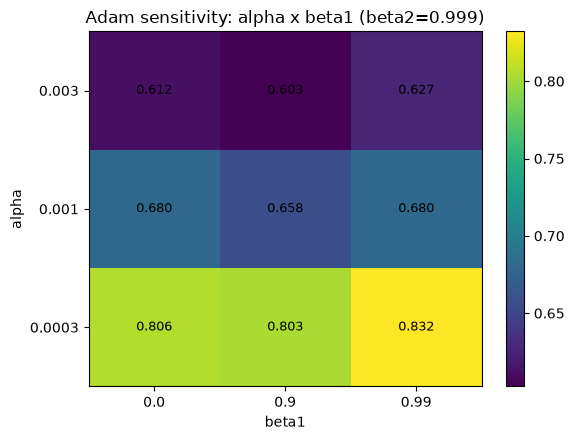

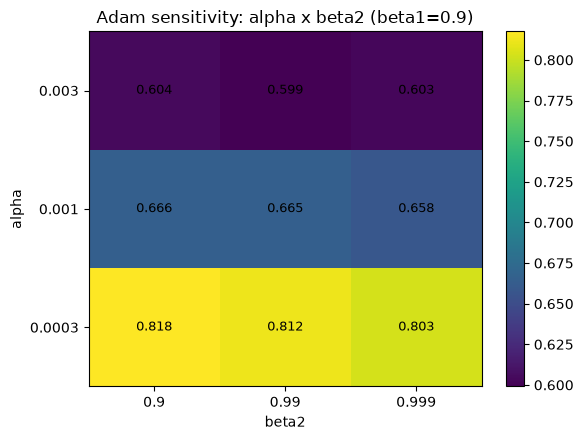

Locked standard Adam hyperparameters: {'lr': 0.003, 'beta1': 0.9, 'beta2': 0.99}


In [11]:
alpha_grid = [3e-4, 1e-3, 3e-3]
beta1_grid = [0.0, 0.9, 0.99]
beta2_grid = [0.90, 0.99, 0.999]

heatmap_b1_rows = []
for alpha in alpha_grid:
    for beta1 in beta1_grid:
        cfg = TrainConfig("adam", alpha, HEATMAP_UPDATES, beta1=beta1, beta2=0.999)
        run = train_controlled(cfg, BASE_SEED)
        heatmap_b1_rows.append({"alpha": alpha, "beta1": beta1,
                                "best_val_loss": run["selected_val_metrics"]["loss"],
                                "best_val_macro_f1": run["selected_val_metrics"]["macro_f1"]})

heatmap_b2_rows = []
for alpha in alpha_grid:
    for beta2 in beta2_grid:
        cfg = TrainConfig("adam", alpha, HEATMAP_UPDATES, beta1=0.9, beta2=beta2)
        run = train_controlled(cfg, BASE_SEED)
        heatmap_b2_rows.append({"alpha": alpha, "beta2": beta2,
                                "best_val_loss": run["selected_val_metrics"]["loss"],
                                "best_val_macro_f1": run["selected_val_metrics"]["macro_f1"]})

heatmap_b1 = pd.DataFrame(heatmap_b1_rows)
heatmap_b2 = pd.DataFrame(heatmap_b2_rows)
heatmap_b1.to_csv(RESULTS_DIR / "adam_alpha_beta1_heatmap.csv", index=False)
heatmap_b2.to_csv(RESULTS_DIR / "adam_alpha_beta2_heatmap.csv", index=False)

def draw_heatmap(table, row, col, value, title, path):
    pivot = table.pivot(index=row, columns=col, values=value).sort_index(ascending=False)
    fig, ax = plt.subplots(figsize=(6, 4.5))
    im = ax.imshow(pivot.values, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)), [str(x) for x in pivot.columns])
    ax.set_yticks(range(len(pivot.index)), [str(x) for x in pivot.index])
    ax.set_xlabel(col); ax.set_ylabel(row); ax.set_title(title)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.iat[i,j]:.3f}", ha="center", va="center", fontsize=9)
    fig.colorbar(im, ax=ax); fig.tight_layout(); fig.savefig(path, dpi=160, bbox_inches="tight"); plt.show()

draw_heatmap(heatmap_b1, "alpha", "beta1", "best_val_loss",
             "Adam sensitivity: alpha x beta1 (beta2=0.999)", FIG_DIR / "adam_alpha_beta1_heatmap.png")
draw_heatmap(heatmap_b2, "alpha", "beta2", "best_val_loss",
             "Adam sensitivity: alpha x beta2 (beta1=0.9)", FIG_DIR / "adam_alpha_beta2_heatmap.png")

# Keep the Part 3 optimizer genuinely standard Adam: beta1 stays at 0.9.
# The alpha x beta1 grid remains a sensitivity analysis; beta1=0 is handled as its
# own required RMSProp-like ablation rather than silently becoming the Part 3 baseline.
best_adam_row = heatmap_b2.sort_values(["best_val_loss", "best_val_macro_f1"], ascending=[True, False]).iloc[0]
BEST_ADAM = {"lr": float(best_adam_row.alpha), "beta1": 0.9, "beta2": float(best_adam_row.beta2)}
print("Locked standard Adam hyperparameters:", BEST_ADAM)

### 11. Seven optimizer ablations across controlled seeds

In [12]:
selected_lr = dict(zip(best_lr_by_condition.condition, best_lr_by_condition.lr))
selected_lr["Adam"] = BEST_ADAM["lr"]

main_runs, history_frames, summary_rows = {}, [], []
for label, spec in OPTIMIZER_SPECS.items():
    for seed in SEEDS:
        beta1 = BEST_ADAM["beta1"] if label == "Adam" else spec["beta1"]
        beta2 = BEST_ADAM["beta2"] if label == "Adam" else spec["beta2"]
        cfg = TrainConfig(
            optimizer_name=spec["optimizer_name"], lr=float(selected_lr[label]),
            max_updates=MAIN_UPDATES, beta1=beta1, beta2=beta2,
            weight_decay=spec["weight_decay"], early_stopping_patience=None,
            selection_metric="val_loss", restore_best=True,
        )
        run = train_controlled(cfg, seed)
        main_runs[(label, seed)] = run
        h = run["history"].copy(); h["condition"] = label
        history_frames.append(h)
        reached = h[h.val_loss <= LOSS_THRESHOLD]
        summary_rows.append({
            "condition": label, "seed": seed, "lr": cfg.lr,
            "beta1": beta1, "beta2": beta2, "weight_decay": cfg.weight_decay,
            "best_val_loss": run["selected_val_metrics"]["loss"],
            "best_val_macro_f1": run["selected_val_metrics"]["macro_f1"],
            "best_val_balanced_accuracy": run["selected_val_metrics"]["balanced_accuracy"],
            "best_update": run["best_update"],
            "updates_to_threshold": int(reached.iloc[0]["update"]) if len(reached) else np.nan,
            "time_to_threshold_sec": float(reached.iloc[0]["wall_time_sec"]) if len(reached) else np.nan,
            "train_val_loss_gap_at_budget": float(h.iloc[-1].val_loss - h.iloc[-1].train_loss),
            "train_val_macro_f1_gap_at_budget": float(h.iloc[-1].train_macro_f1 - h.iloc[-1].val_macro_f1),
            "wall_time_sec": run["wall_time_sec"],
            "gradient_evaluations": run["gradient_evaluations"],
        })

optimizer_history = pd.concat(history_frames, ignore_index=True)
optimizer_summary = pd.DataFrame(summary_rows)
optimizer_history.to_csv(RESULTS_DIR / "optimizer_trajectories.csv", index=False)
optimizer_summary.to_csv(RESULTS_DIR / "optimizer_seed_summary.csv", index=False)
display(optimizer_summary)

,condition,seed,lr,beta1,beta2,weight_decay,best_val_loss,best_val_macro_f1,best_val_balanced_accuracy,best_update,updates_to_threshold,time_to_threshold_sec,train_val_loss_gap_at_budget,train_val_macro_f1_gap_at_budget,wall_time_sec,gradient_evaluations
0,SGD no momentum,42,0.100,0.0,0.000,0.0000,0.610703,0.581552,0.749447,1568,NaN,NaN,0.078813,0.023412,3.402912,1600
1,SGD no momentum,202,0.100,0.0,0.000,0.0000,0.651595,0.496068,0.719794,1248,NaN,NaN,0.131429,0.037017,3.545783,1600
2,SGD no momentum,7641,0.100,0.0,0.000,0.0000,0.633438,0.517356,0.725265,1344,NaN,NaN,0.136148,0.055605,3.456120,1600
3,SGD momentum,42,0.050,0.9,0.000,0.0000,0.588376,0.578664,0.772573,832,832.0,1.894819,0.303941,0.097913,3.684365,1600
4,SGD momentum,202,0.050,0.9,0.000,0.0000,0.590625,0.570205,0.760841,1312,1312.0,3.005557,0.296122,0.067818,3.651207,1600
5,SGD momentum,7641,0.050,0.9,0.000,0.0000,0.587228,0.571837,0.757955,800,800.0,1.800258,0.289052,0.082214,3.605997,1600
6,Nesterov momentum,42,0.050,0.9,0.000,0.0000,0.607178,0.550308,0.747990,480,NaN,NaN,0.290921,0.077199,3.985291,1600
7,Nesterov momentum,202,0.050,0.9,0.000,0.0000,0.606414,0.518042,0.749270,576,NaN,NaN,0.331385,0.077496,3.669723,1600
8,Nesterov momentum,7641,0.050,0.9,0.000,0.0000,0.590139,0.570548,0.747110,800,800.0,1.867573,0.327061,0.103424,3.677226,1600
9,Adam,42,0.003,0.9,0.990,0.0000,0.599047,0.566645,0.752769,608,608.0,1.668743,0.298445,0.052957,4.342823,1600


### 12. Trajectories, compute threshold, and stability bands

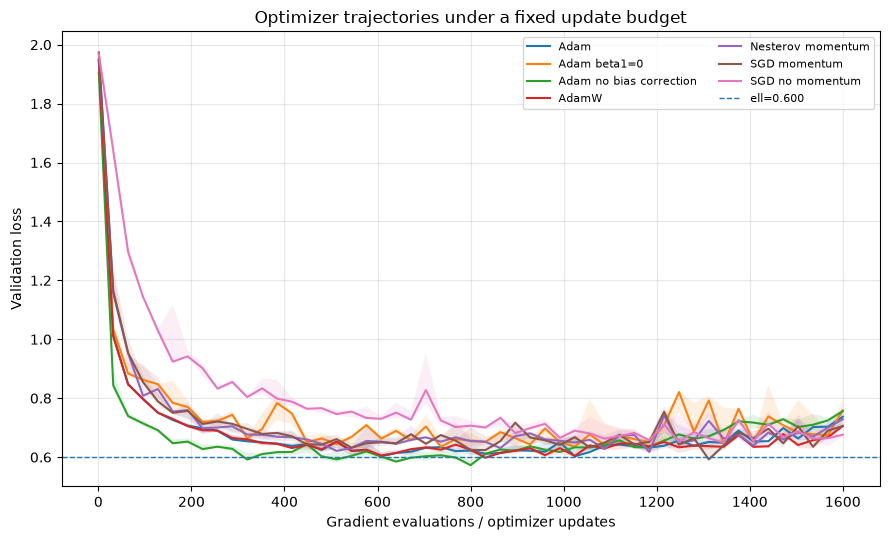

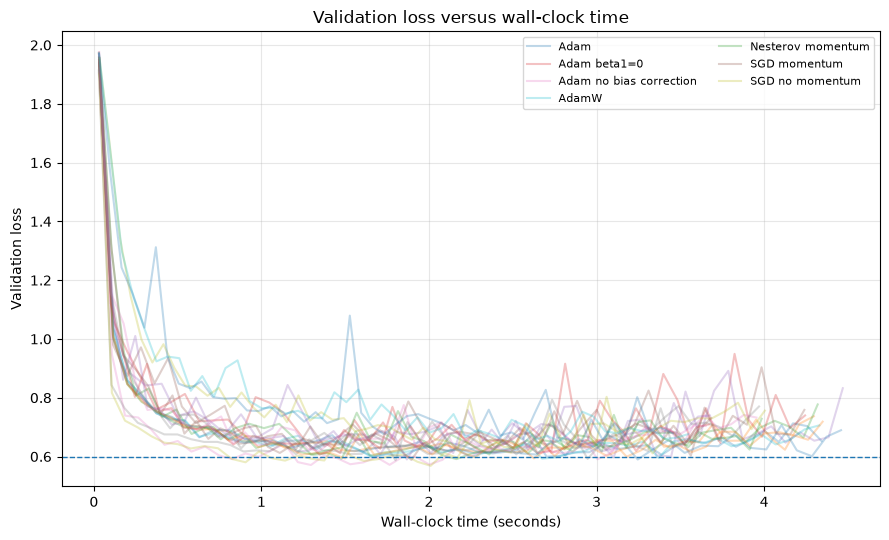

,condition,median_val_loss,iqr_val_loss,median_val_macro_f1,std_val_macro_f1,median_updates_to_threshold,median_time_to_threshold_sec,median_generalization_gap,median_wall_time_sec
2,Adam no bias correction,0.571215,0.019444,0.586169,0.024485,320.0,0.824422,0.461959,3.969543
5,SGD momentum,0.588376,0.001699,0.571837,0.004487,832.0,1.894819,0.296122,3.651207
3,AdamW,0.592732,0.001855,0.574122,0.022769,608.0,1.659503,0.348107,4.349254
0,Adam,0.599047,0.004087,0.566645,0.002901,608.0,1.668743,0.361751,4.319733
1,Adam beta1=0,0.602830,0.007330,0.579603,0.004779,1088.0,3.101002,0.327181,4.244391
4,Nesterov momentum,0.606414,0.008519,0.550308,0.026481,800.0,1.867573,0.327061,3.677226
6,SGD no momentum,0.633438,0.020446,0.517356,0.044501,NaN,NaN,0.131429,3.456120


In [13]:
plt.figure(figsize=(9, 5.5))
for label, group in optimizer_history.groupby("condition"):
    pivot = group.pivot_table(index="gradient_evaluations", columns="seed", values="val_loss")
    med = pivot.median(axis=1); q1 = pivot.quantile(.25, axis=1); q3 = pivot.quantile(.75, axis=1)
    plt.plot(med.index, med.values, label=label)
    if len(pivot.columns) > 1:
        plt.fill_between(med.index, q1.values, q3.values, alpha=.12)
plt.axhline(LOSS_THRESHOLD, linestyle="--", linewidth=1, label=f"ell={LOSS_THRESHOLD:.3f}")
plt.xlabel("Gradient evaluations / optimizer updates")
plt.ylabel("Validation loss")
plt.title("Optimizer trajectories under a fixed update budget")
plt.grid(True, alpha=.3); plt.legend(fontsize=8, ncol=2); plt.tight_layout()
plt.savefig(FIG_DIR / "optimizer_val_loss_vs_gradient_evaluations.png", dpi=160, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5.5))
for label, group in optimizer_history.groupby("condition"):
    for seed, g in group.groupby("seed"):
        plt.plot(g.wall_time_sec, g.val_loss, alpha=.28, label=label if seed == SEEDS[0] else None)
plt.axhline(LOSS_THRESHOLD, linestyle="--", linewidth=1)
plt.xlabel("Wall-clock time (seconds)")
plt.ylabel("Validation loss")
plt.title("Validation loss versus wall-clock time")
plt.grid(True, alpha=.3); plt.legend(fontsize=8, ncol=2); plt.tight_layout()
plt.savefig(FIG_DIR / "optimizer_val_loss_vs_wall_time.png", dpi=160, bbox_inches="tight")
plt.show()

stability_summary = optimizer_summary.groupby("condition").agg(
    median_val_loss=("best_val_loss", "median"),
    iqr_val_loss=("best_val_loss", lambda x: x.quantile(.75)-x.quantile(.25)),
    median_val_macro_f1=("best_val_macro_f1", "median"),
    std_val_macro_f1=("best_val_macro_f1", "std"),
    median_updates_to_threshold=("updates_to_threshold", "median"),
    median_time_to_threshold_sec=("time_to_threshold_sec", "median"),
    median_generalization_gap=("train_val_loss_gap_at_budget", "median"),
    median_wall_time_sec=("wall_time_sec", "median"),
).reset_index().sort_values(["median_val_loss", "median_val_macro_f1"], ascending=[True, False])
stability_summary.to_csv(RESULTS_DIR / "optimizer_stability_summary.csv", index=False)
display(stability_summary)

### 13. Lock configurations, then evaluate the test set once at the end

Best overall optimizer condition by validation: Adam no bias correction
Part 3 standard-Adam configuration: {'optimizer_name': 'adam', 'lr': 0.003, 'beta1': 0.9, 'beta2': 0.99, 'batch_size': 512, 'main_update_budget': 1600, 'selection_rule': 'coarse validation heatmaps; lowest validation loss with Macro-F1 tie-break'}


,method,seed,best_val_loss,best_val_macro_f1,test_accuracy,test_macro_f1,test_balanced_accuracy,wall_time_sec,gradient_evaluations,function_evaluations,notes
0,SGD no momentum,42,0.610703,0.581552,0.668681,0.574076,0.730273,3.402912,1600,0,"{""batch_size"": 512, ""beta1"": 0.0, ""beta2"": 0.0..."
1,SGD no momentum,202,0.651595,0.496068,0.593199,0.497778,0.717982,3.545783,1600,0,"{""batch_size"": 512, ""beta1"": 0.0, ""beta2"": 0.0..."
2,SGD no momentum,7641,0.633438,0.517356,0.630470,0.529548,0.725096,3.456120,1600,0,"{""batch_size"": 512, ""beta1"": 0.0, ""beta2"": 0.0..."
3,SGD momentum,42,0.588376,0.578664,0.664248,0.566574,0.741593,3.684365,1600,0,"{""batch_size"": 512, ""beta1"": 0.9, ""beta2"": 0.0..."
4,SGD momentum,202,0.590625,0.570205,0.674280,0.567772,0.754718,3.651207,1600,0,"{""batch_size"": 512, ""beta1"": 0.9, ""beta2"": 0.0..."
5,SGD momentum,7641,0.587228,0.571837,0.628799,0.556918,0.730178,3.605997,1600,0,"{""batch_size"": 512, ""beta1"": 0.9, ""beta2"": 0.0..."
6,Nesterov momentum,42,0.607178,0.550308,0.632231,0.541278,0.720218,3.985291,1600,0,"{""batch_size"": 512, ""beta1"": 0.9, ""beta2"": 0.0..."
7,Nesterov momentum,202,0.606414,0.518042,0.634967,0.521487,0.739283,3.669723,1600,0,"{""batch_size"": 512, ""beta1"": 0.9, ""beta2"": 0.0..."
8,Nesterov momentum,7641,0.590139,0.570548,0.649533,0.564598,0.729758,3.677226,1600,0,"{""batch_size"": 512, ""beta1"": 0.9, ""beta2"": 0.0..."
9,Adam,42,0.599047,0.566645,0.656366,0.565117,0.743569,4.342823,1600,0,"{""batch_size"": 512, ""beta1"": 0.9, ""beta2"": 0.9..."


,precision,recall,f1-score,support
Cover_Type_1,0.716207,0.689863,0.702788,204548.000000
Cover_Type_2,0.807210,0.601227,0.689156,273549.000000
Cover_Type_3,0.661802,0.683023,0.672245,34523.000000
Cover_Type_4,0.383746,0.806257,0.519995,2653.000000
Cover_Type_5,0.146413,0.861226,0.250277,9166.000000
Cover_Type_6,0.401256,0.632715,0.491079,16769.000000
Cover_Type_7,0.476487,0.930671,0.630281,19804.000000
accuracy,0.656366,0.656366,0.656366,0.656366
macro avg,0.513303,0.743569,0.565117,561012.000000
weighted avg,0.728474,0.656366,0.677116,561012.000000


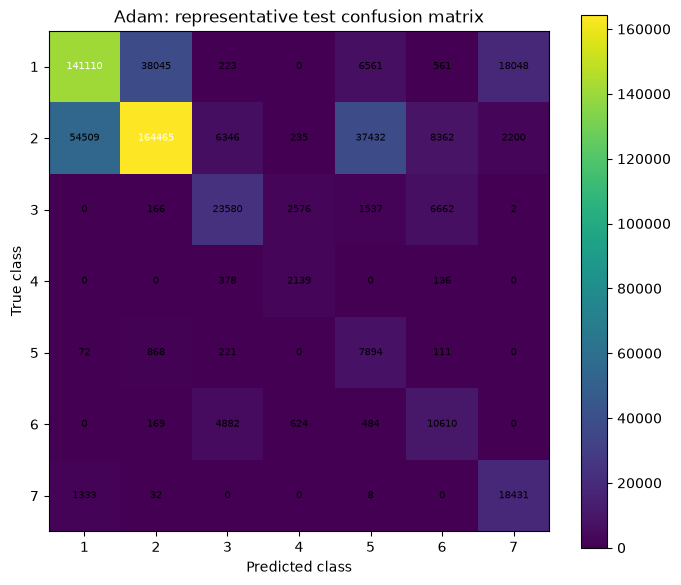

,precision,recall,f1-score,support
Cover_Type_1,0.695504,0.759880,0.726269,204548.00000
Cover_Type_2,0.840378,0.594672,0.696491,273549.00000
Cover_Type_3,0.668865,0.646236,0.657356,34523.00000
Cover_Type_4,0.380136,0.802111,0.515816,2653.00000
Cover_Type_5,0.169248,0.831006,0.281221,9166.00000
Cover_Type_6,0.417439,0.671477,0.514825,16769.00000
Cover_Type_7,0.547489,0.913098,0.684534,19804.00000
accuracy,0.676460,0.676460,0.676460,0.67646
macro avg,0.531294,0.745497,0.582359,561012.00000
weighted avg,0.740879,0.676460,0.691448,561012.00000


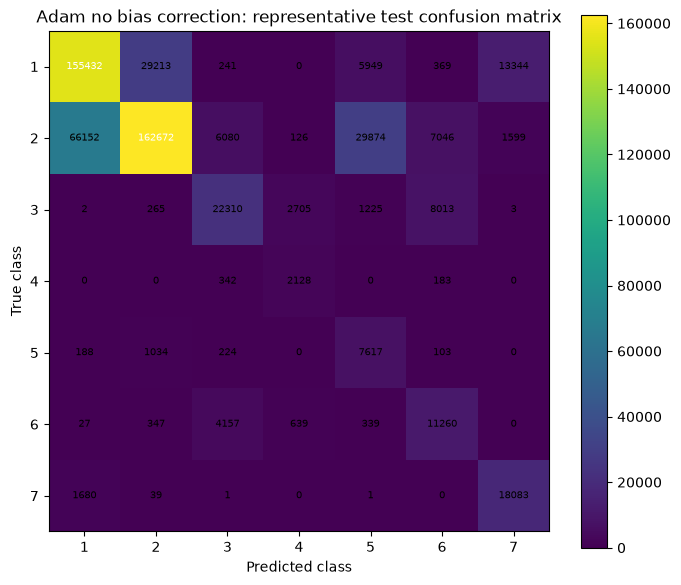

In [14]:
best_optimizer_condition = stability_summary.iloc[0].condition
best_adam_config = {
    "optimizer_name": "adam",
    **BEST_ADAM,
    "batch_size": SL_BATCH_SIZE,
    "main_update_budget": MAIN_UPDATES,
    "selection_rule": "coarse validation heatmaps; lowest validation loss with Macro-F1 tie-break",
}
save_json(RESULTS_DIR / "best_adam_config.json", best_adam_config)
save_json(RESULTS_DIR / "best_optimizer_config.json", {
    "condition": best_optimizer_condition,
    "selected_lr": float(selected_lr[best_optimizer_condition]),
    "main_update_budget": MAIN_UPDATES,
    "loss_threshold": LOSS_THRESHOLD,
})
print("Best overall optimizer condition by validation:", best_optimizer_condition)
print("Part 3 standard-Adam configuration:", best_adam_config)

final_rows, reports, cms = [], {}, {}
if not SMOKE_TEST:
    for (label, seed), run in main_runs.items():
        row, report, cm, _ = evaluate_test_locked(run, label)
        final_rows.append(row); reports[(label, seed)] = report; cms[(label, seed)] = cm
    final_metric_table = pd.DataFrame(final_rows)
    final_metric_table.to_csv(RESULTS_DIR / "final_metric_table.csv", index=False)
    display(final_metric_table)

    # Per-class behavior for the representative standard Adam and best overall optimizer runs.
    for label in sorted(set(["Adam", best_optimizer_condition])):
        subset = final_metric_table[final_metric_table.method.eq(label)]
        rep_seed = representative_seed(subset)
        reports[(label, rep_seed)].to_csv(RESULTS_DIR / f"classification_report_{label.replace(' ','_')}.csv")
        cms[(label, rep_seed)].to_csv(RESULTS_DIR / f"confusion_matrix_{label.replace(' ','_')}.csv")
        display(reports[(label, rep_seed)])
        plot_confusion_matrix(cms[(label, rep_seed)], f"{label}: representative test confusion matrix",
                              FIG_DIR / f"confusion_matrix_{label.replace(' ','_')}.png")
else:
    print("Smoke test mode: final held-out test evaluation intentionally skipped.")